# Task 2 — Credit Risk EDA

Expanded EDA to cover core KPIs: dataset shape/integrity (duplicates, constant/high-cardinality columns, date range), missingness detail, class balance if present, numeric summary with skew/kurtosis and outlier depth, categorical coverage, and correlation checks. Figures auto-save to outputs/figures/ via Plotter.

### Setup
Configure paths, plotting defaults, and options for wide displays before loading data.

In [1]:
import sys
sys.path.append('../')

import importlib
import pandas as pd
import numpy as np
from pathlib import Path

from src.visualisation import plotter as plotter_module
from src.preprocessing import eda_utils as eda_utils_module

pd.set_option("display.max_columns", 120)
pd.options.display.float_format = "{:.4f}".format

ROOT = Path("..").resolve()
RAW_PATH = ROOT / "data" / "raw" / "data.csv"
PROCESSED_PATH = ROOT / "data" / "processed" / "xente_processed.csv"
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plotter_module = importlib.reload(plotter_module)
eda_utils_module = importlib.reload(eda_utils_module)
Plotter = plotter_module.Plotter
from src.preprocessing.eda_utils import (
    missingness_summary,
    top_frequencies,
    flag_outliers_iqr,
    constant_columns,
    cardinality_report,
    class_balance,
)
plotter = Plotter(figures_dir=FIG_DIR)

print(f"Raw path: {RAW_PATH}")
print(f"Processed path (will write): {PROCESSED_PATH}")

Raw path: C:\BackUp\web-projects\tenx\credit-risk-model-week4\data\raw\data.csv
Processed path (will write): C:\BackUp\web-projects\tenx\credit-risk-model-week4\data\processed\xente_processed.csv


### Helper utilities
Reusable helpers for missingness summary, top frequencies, constant/high-cardinality detection, outlier flagging, and class balance (imported from src/preprocessing/eda_utils).

In [2]:
# Helpers imported from src.preprocessing.eda_utils
# (missingness_summary, top_frequencies, flag_outliers_iqr, constant_columns,
#  cardinality_report, class_balance)

### Data loading and typing
Read raw CSV, coerce transaction timestamps, and cast selected identifiers to categoricals for lighter memory and clearer cardinality.

In [3]:
# Load raw data
raw_df = pd.read_csv(RAW_PATH, low_memory=False)
print(f"Raw shape: {raw_df.shape}")

# Basic cleaning: datetime parse, categoricals, numeric coercion, dedupe
raw_df["TransactionStartTime"] = pd.to_datetime(raw_df["TransactionStartTime"], errors="coerce")
cat_cols = [
    "BatchId",
    "AccountId",
    "SubscriptionId",
    "CustomerId",
    "CurrencyCode",
    "CountryCode",
    "ProviderId",
    "ProductId",
    "ProductCategory",
    "ChannelId",
    "PricingStrategy",
]
for col in cat_cols:
    if col in raw_df.columns:
        raw_df[col] = raw_df[col].astype("category")

clean_df = raw_df.copy()
for col in ["Amount", "Value"]:
    if col in clean_df.columns:
        clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

clean_df = clean_df.drop_duplicates().reset_index(drop=True)
print(f"Clean shape: {clean_df.shape}")

clean_df.head()

Raw shape: (95662, 16)
Clean shape: (95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0000,1000,2018-11-15 02:18:49+00:00,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0000,20,2018-11-15 02:19:08+00:00,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0000,500,2018-11-15 02:44:21+00:00,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0000,21800,2018-11-15 03:32:55+00:00,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0000,644,2018-11-15 03:34:21+00:00,2,0


### Dataset integrity snapshot
Count rows/columns, duplicates, constant columns, dtype distribution, and top cardinality to spot structural issues early.

In [4]:
# Dataset overview & integrity
overview = {
    "rows": len(clean_df),
    "columns": clean_df.shape[1],
    "duplicates": int(clean_df.duplicated().sum()),
    "duplicate_pct": round(clean_df.duplicated().mean() * 100, 3),
    "constant_cols": len(constant_columns(clean_df)),
}

if "TransactionStartTime" in clean_df.columns:
    overview["date_min"] = clean_df["TransactionStartTime"].min()
    overview["date_max"] = clean_df["TransactionStartTime"].max()

const_cols_list = constant_columns(clean_df)
overview["constant_cols_list"] = ", \
None"

display(pd.Series(overview))

dtype_counts = clean_df.dtypes.value_counts()
display(dtype_counts.to_frame(name="count"))

cardinal = cardinality_report(clean_df, cat_cols, max_rows=12)
if not cardinal.empty:
    display(cardinal)


rows                                      95662
columns                                      16
duplicates                                    0
duplicate_pct                            0.0000
constant_cols                                 2
date_min              2018-11-15 02:18:49+00:00
date_max              2019-02-13 10:01:28+00:00
constant_cols_list                       , None
dtype: object

,count
int64,2
category,1
object,1
category,1
category,1
category,1
category,1
category,1
category,1
category,1


,column,unique,unique_pct
0,BatchId,94809,0.9911
3,CustomerId,3742,0.0391
1,AccountId,3633,0.0380
2,SubscriptionId,3627,0.0379
7,ProductId,23,0.0002
8,ProductCategory,9,0.0001
6,ProviderId,6,0.0001
9,ChannelId,4,0.0000
10,PricingStrategy,4,0.0000
5,CountryCode,1,0.0000


### Missingness overview
Inspect per-column missing percentages with dtypes to decide on imputations or drops.

In [5]:
# Missingness detail
# Run missingness on raw data before any cleaning/dup removal
missing_tbl = missingness_summary(raw_df)
display(missing_tbl.head(20))

,missing_pct,dtype,non_null
TransactionId,0.0000,object,95662.0000
BatchId,0.0000,category,95662.0000
AccountId,0.0000,category,95662.0000
SubscriptionId,0.0000,category,95662.0000
CustomerId,0.0000,category,95662.0000
CurrencyCode,0.0000,category,95662.0000
CountryCode,0.0000,category,95662.0000
ProviderId,0.0000,category,95662.0000
ProductId,0.0000,category,95662.0000
ProductCategory,0.0000,category,95662.0000


### Class balance
Check candidate label columns for imbalance; note if no target exists yet.

In [6]:
# Class/label balance (if available)
target_candidates = ["FraudResult", "fraud", "is_fraud", "label", "target"]
balance = class_balance(clean_df, target_candidates)
if not balance.empty:
    display(balance)
else:
    print(f"No target column found among candidates: {target_candidates}")


,FraudResult,count,share
0,0,95469,0.9980
1,1,193,0.0020


### Persist snapshot
Write the cleaned/typed data to processed storage for downstream modeling steps.

In [7]:
# Save a lightly cleaned version for downstream steps
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
clean_df.to_csv(PROCESSED_PATH, index=False)
print(f"Wrote processed snapshot to {PROCESSED_PATH}")

Wrote processed snapshot to C:\BackUp\web-projects\tenx\credit-risk-model-week4\data\processed\xente_processed.csv


### Numeric summary
Describe numeric fields with percentiles plus skew/kurtosis to flag heavy tails or non-normality.

In [8]:
num_cols = [col for col in ["Amount", "Value"] if col in clean_df.columns]

num_summary = (
    clean_df[num_cols]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99])
    .T.assign(skew=clean_df[num_cols].skew(), kurtosis=clean_df[num_cols].kurtosis())
)
num_summary

,count,mean,std,min,25%,50%,75%,90%,99%,max,skew,kurtosis
Amount,95662.0000,6717.8464,123306.7972,-1000000.0000,-50.0000,1000.0000,2800.0000,10000.0000,80000.0000,9880000.0000,51.0985,3363.1277
Value,95662.0000,9900.5839,123122.0878,2.0000,275.0000,1000.0000,5000.0000,11200.0000,90000.0000,9880000.0000,51.2911,3378.0693


### Numeric distributions
Plot histograms with KDE to visualize skewness and outlier tails for key numeric columns.

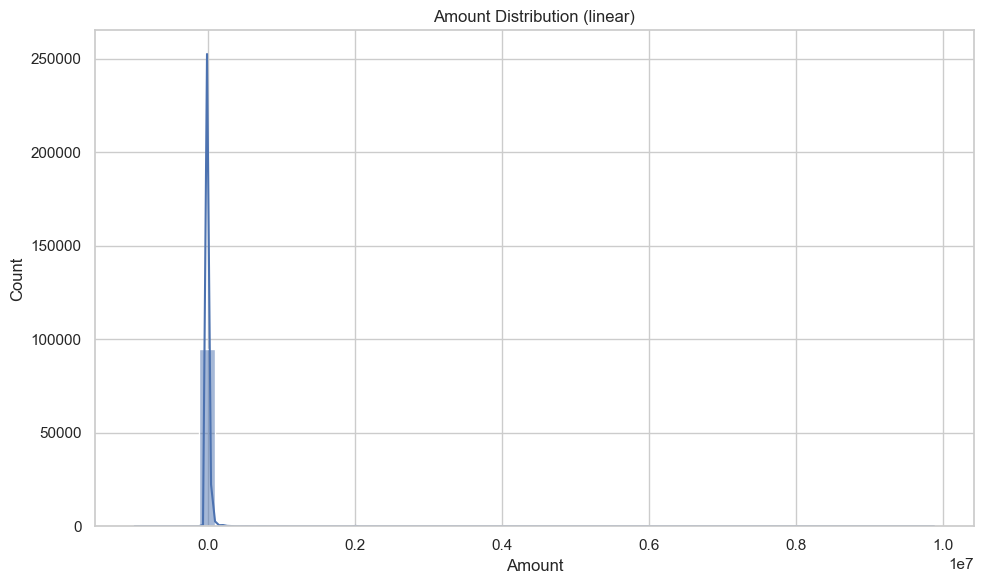

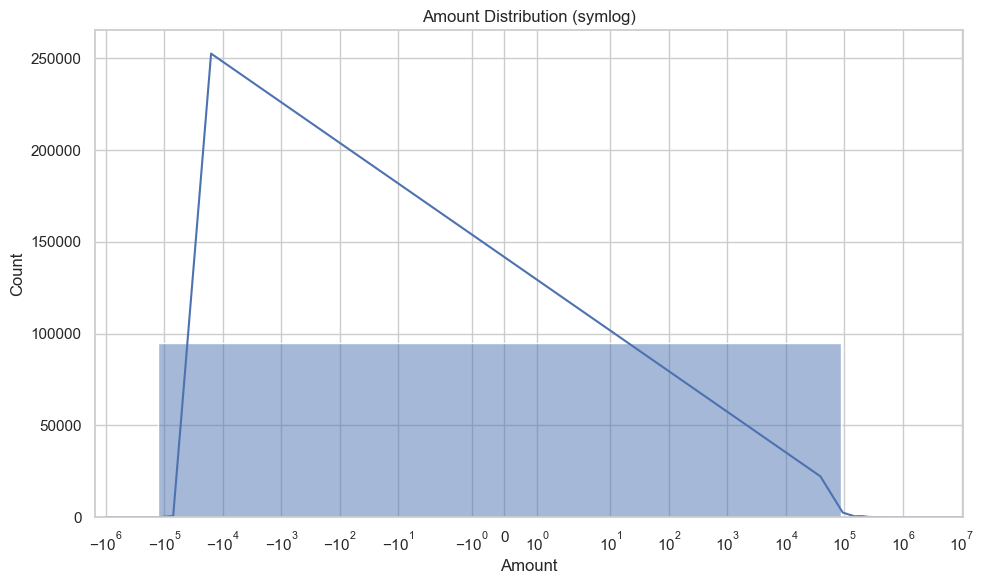

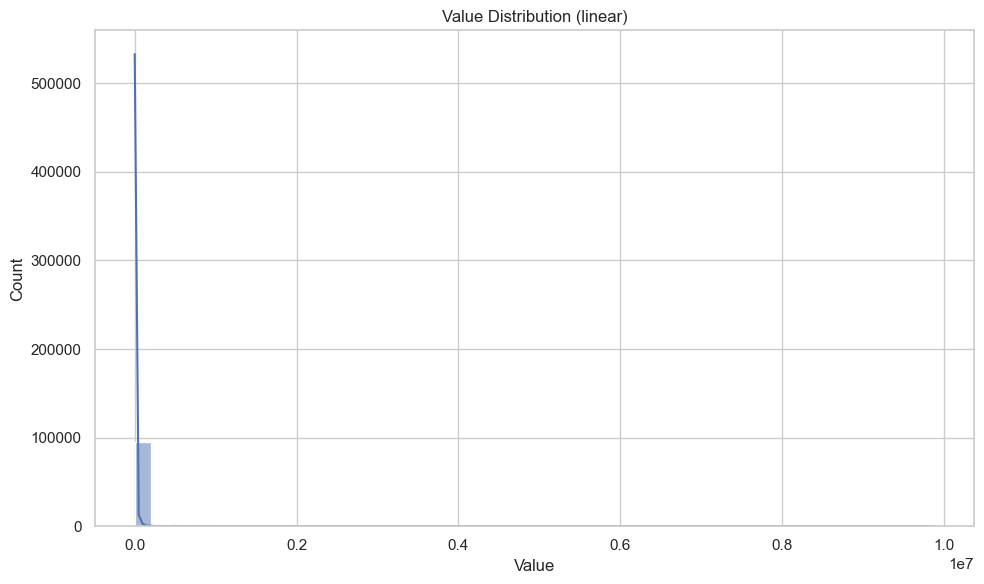

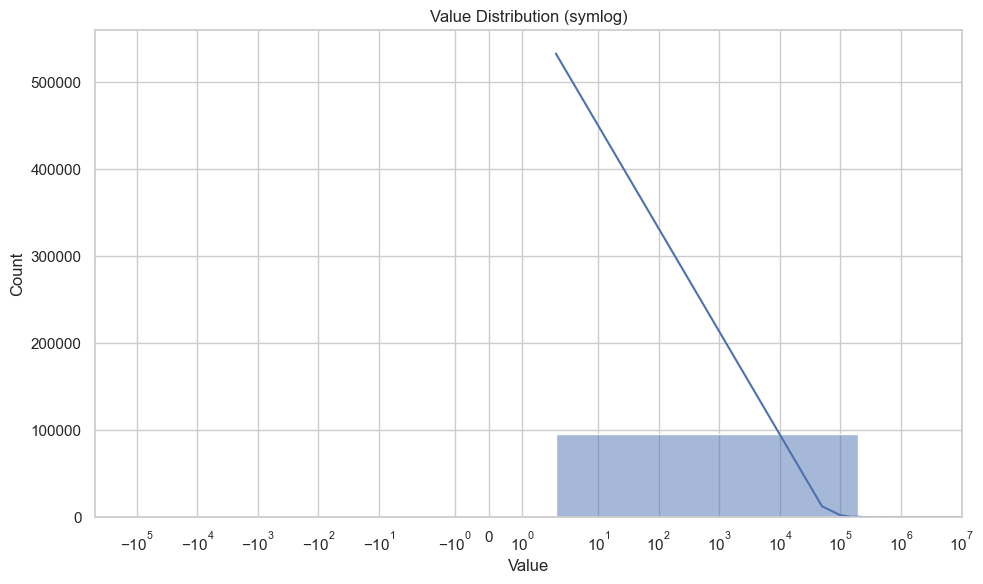

In [9]:
# Numeric distributions (linear and log-scale)
for col in num_cols:
    plotter.plot_histogram(clean_df, col, title=f"{col} Distribution (linear)", bins=50, log_scale=False)
    plotter.plot_histogram(clean_df, col, title=f"{col} Distribution (symlog)", bins=50, log_scale=True)


### Categorical coverage
Show top frequency tables and bar plots for key categorical fields to understand dominant buckets and tails.

,ProductCategory,count,share
0,financial_services,45405,0.4746
1,airtime,45027,0.4707
2,utility_bill,1920,0.0201
3,data_bundles,1613,0.0169
4,tv,1279,0.0134
5,ticket,216,0.0023
6,movies,175,0.0018
7,transport,25,0.0003
8,other,2,0.0000


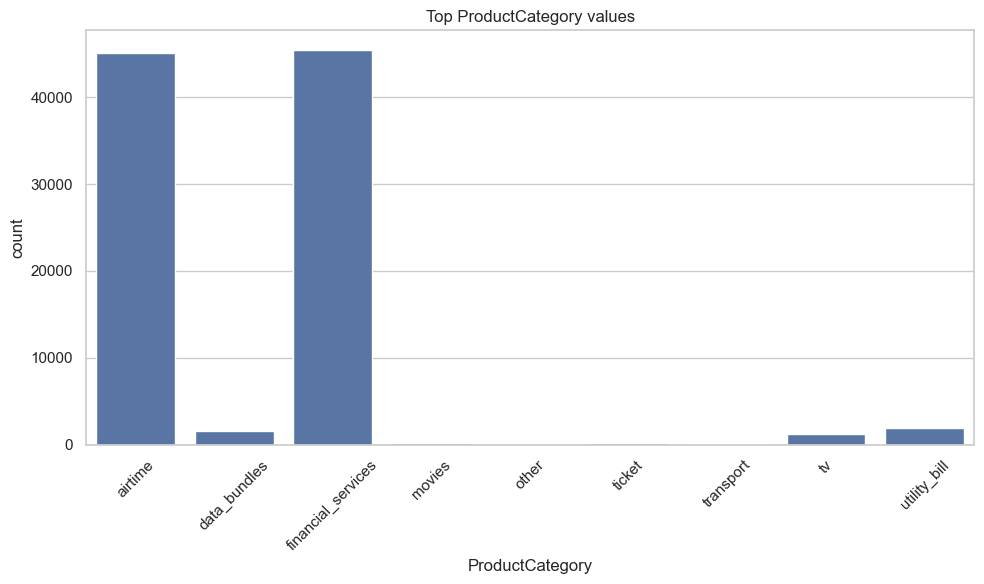

,ChannelId,count,share
0,ChannelId_3,56935,0.5952
1,ChannelId_2,37141,0.3883
2,ChannelId_5,1048,0.0110
3,ChannelId_1,538,0.0056


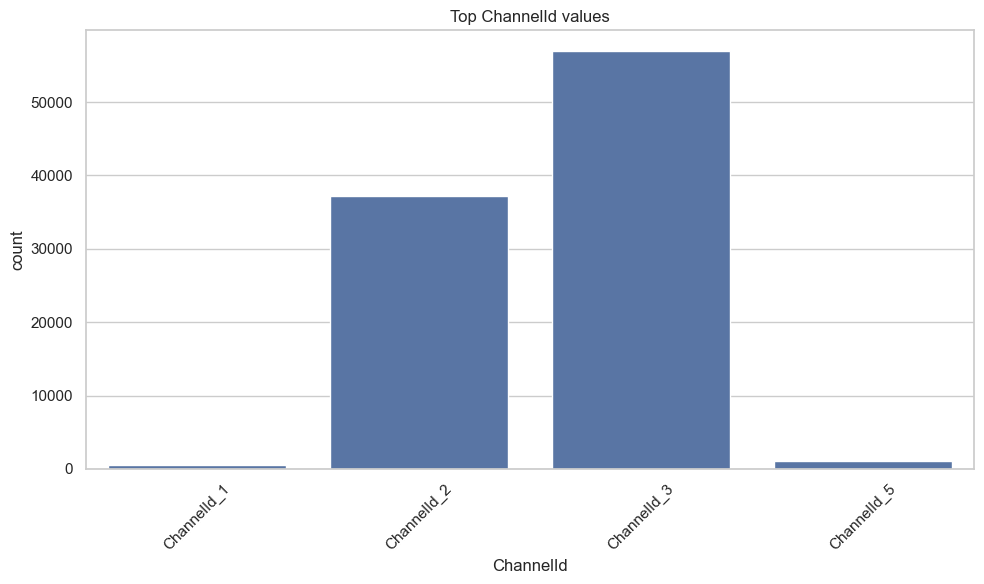

,ProviderId,count,share
0,ProviderId_4,38189,0.3992
1,ProviderId_6,34186,0.3574
2,ProviderId_5,14542,0.1520
3,ProviderId_1,5643,0.0590
4,ProviderId_3,3084,0.0322
5,ProviderId_2,18,0.0002


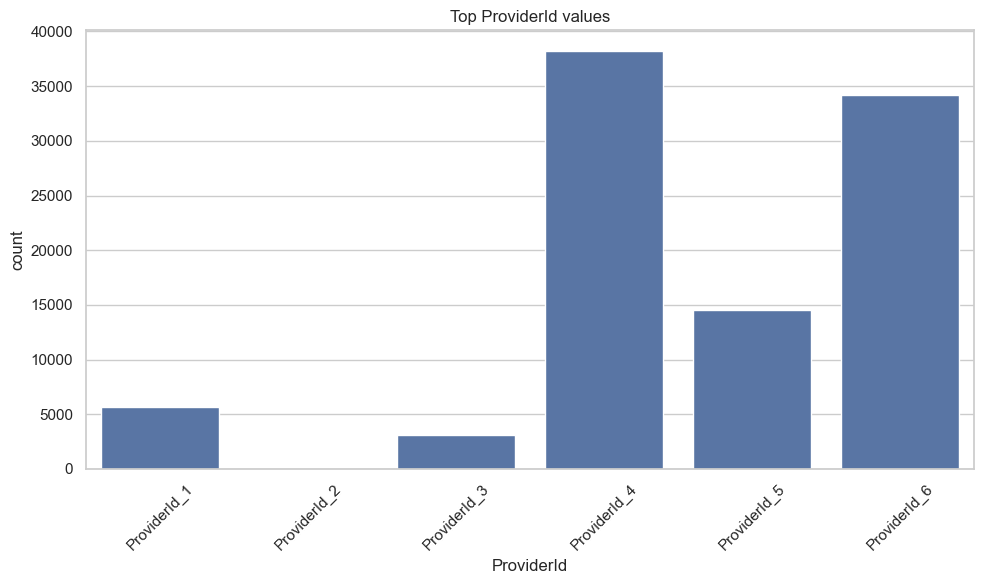

,PricingStrategy,count,share
0,2,79848,0.8347
1,4,13562,0.1418
2,1,1867,0.0195
3,0,385,0.0040


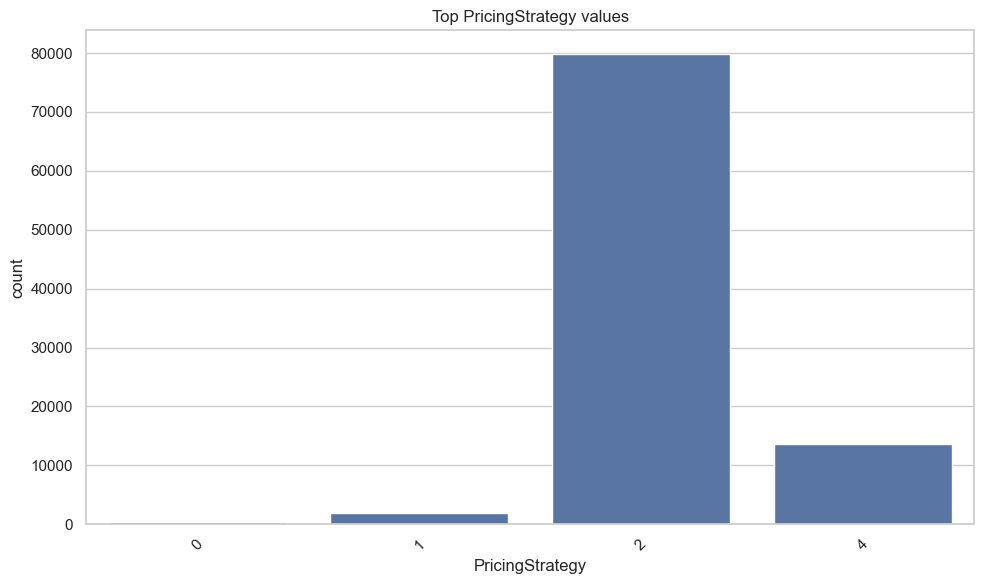

In [10]:
cat_focus = [
    "ProductCategory",
    "ChannelId",
    "ProviderId",
    "PricingStrategy",
]

for col in cat_focus:
    if col in clean_df.columns:
        freq_df = top_frequencies(clean_df, col, n=12)
        display(freq_df)
        plotter.plot_bar(freq_df, x=col, y="count", title=f"Top {col} values")

### Correlation checks
Derive time-based features then compute Pearson and Spearman correlations across numeric fields to spot linear and monotonic relationships. Add heatmaps for a quick visual scan.

Pearson correlation (numeric):


,Amount,Value,FraudResult,txn_hour,txn_day,txn_month,txn_year
Amount,1.0000,0.9897,0.5574,-0.0016,-0.0039,-0.0091,0.0107
Value,0.9897,1.0000,0.5667,0.0005,-0.0241,-0.0105,0.0120
FraudResult,0.5574,0.5667,1.0000,0.0083,-0.0086,-0.0089,0.0098
txn_hour,-0.0016,0.0005,0.0083,1.0000,-0.0195,0.0122,-0.0096
txn_day,-0.0039,-0.0241,-0.0086,-0.0195,1.0000,0.2078,-0.2475
txn_month,-0.0091,-0.0105,-0.0089,0.0122,0.2078,1.0000,-0.9962
txn_year,0.0107,0.0120,0.0098,-0.0096,-0.2475,-0.9962,1.0000


Spearman correlation (numeric):


,Amount,Value,FraudResult,txn_hour,txn_day,txn_month,txn_year
Amount,1.0000,0.4974,0.0735,-0.0167,0.0426,-0.0405,0.0505
Value,0.4974,1.0000,0.0770,-0.0206,-0.1421,-0.0522,0.0652
FraudResult,0.0735,0.0770,1.0000,0.0082,-0.0086,-0.0047,0.0098
txn_hour,-0.0167,-0.0206,0.0082,1.0000,-0.0204,0.0222,-0.0102
txn_day,0.0426,-0.1421,-0.0086,-0.0204,1.0000,0.0393,-0.2439
txn_month,-0.0405,-0.0522,-0.0047,0.0222,0.0393,1.0000,-0.9104
txn_year,0.0505,0.0652,0.0098,-0.0102,-0.2439,-0.9104,1.0000


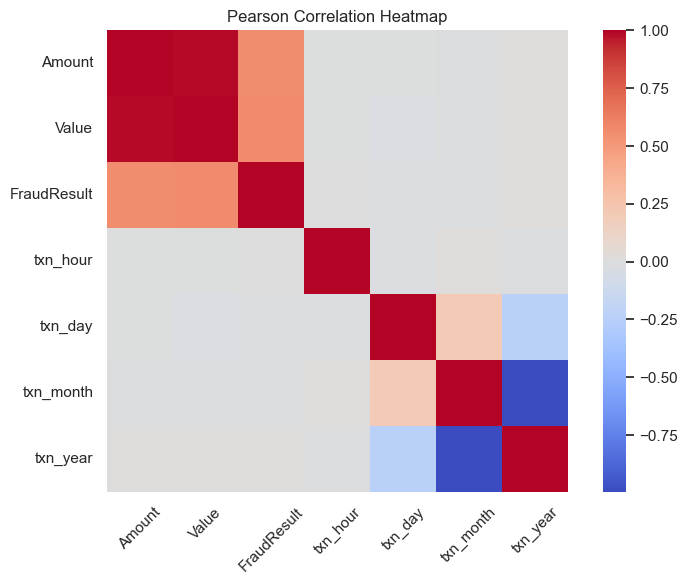

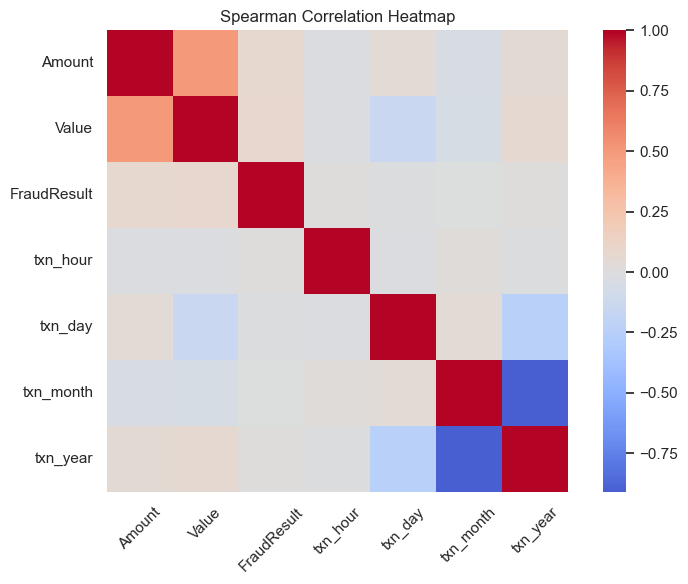

In [11]:
# Temporal feature extracts for later modeling
if "TransactionStartTime" in clean_df.columns:
    clean_df["txn_hour"] = clean_df["TransactionStartTime"].dt.hour
    clean_df["txn_day"] = clean_df["TransactionStartTime"].dt.day
    clean_df["txn_month"] = clean_df["TransactionStartTime"].dt.month
    clean_df["txn_year"] = clean_df["TransactionStartTime"].dt.year

numeric_cols = clean_df.select_dtypes(include=["number"]).columns
corr_pearson = clean_df[numeric_cols].corr(method="pearson")
corr_spearman = clean_df[numeric_cols].corr(method="spearman")

print("Pearson correlation (numeric):")
display(corr_pearson)
print("Spearman correlation (numeric):")
display(corr_spearman)

# Plot heatmaps for visual correlation scan via Plotter
for name, corr_mat in [("Pearson", corr_pearson), ("Spearman", corr_spearman)]:
    # Use the Plotter helper so figures are displayed and auto-saved consistently
    plotter.plot_heatmap(corr_mat, title=f"{name} Correlation Heatmap", annot=False)


### Outlier depth
Quantify IQR-based outlier counts/shares and bounds to guide clipping or winsorization decisions. Add boxplots for visual outlier inspection.

,column,outlier_share,outlier_count,lower_bound,upper_bound
0,Amount,0.2555,24441,-4325.0000,7075.0000
1,Value,0.0943,9021,-6812.5000,12087.5000


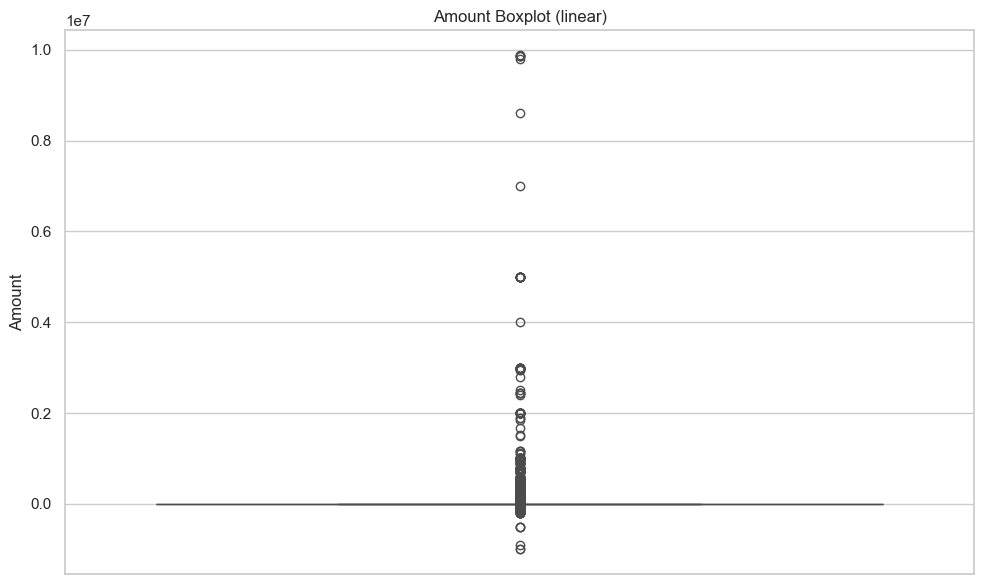

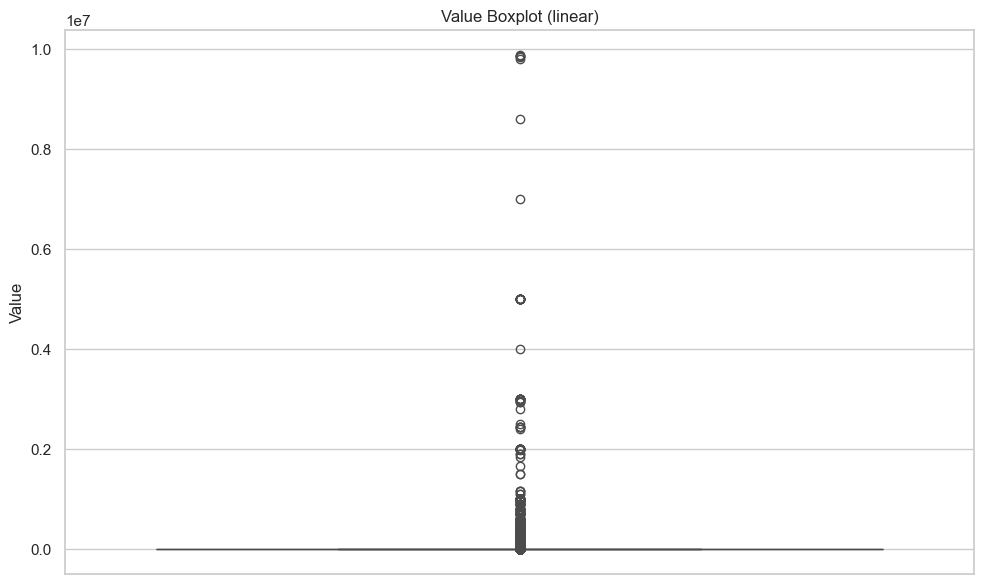

In [12]:
# Outlier depth using IQR + boxplots
outlier_report = []
for col in num_cols:
    series = clean_df[col].dropna()
    if series.empty:
        continue
    mask = flag_outliers_iqr(series)
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_report.append({
        "column": col,
        "outlier_share": mask.mean(),
        "outlier_count": int(mask.sum()),
        "lower_bound": lower,
        "upper_bound": upper,
    })

outlier_df = pd.DataFrame(outlier_report).sort_values("outlier_share", ascending=False)
display(outlier_df)

# Visualize via boxplots (linear and optional log-scale)
for col in num_cols:
    plotter.plot_box(clean_df, y=col, title=f"{col} Boxplot (linear)")


### Insights checklist
Mark findings after running the notebook; update with concrete numbers and decisions.

## Top insights
- [x] Dataset integrity: 95,662 rows × 16 columns; duplicates 0 (0.0%). Constant columns: CurrencyCode, CountryCode. TransactionStartTime range: 2018-11-15 02:18:49+00:00 to 2019-02-13 10:01:28+00:00.
- [x] Missingness: 0% missing for all 16 columns (see missingness table).
- [x] Class balance: FraudResult highly imbalanced — 0: 95,469 (99.8%), 1: 193 (0.2%); plan resampling/thresholding later.
- [x] Numeric shape: Amount mean 6,717.85, median 1,000; Value mean 9,900.58, median 1,000. Both extremely right-skewed (skew > 51, kurtosis > 3,360), suggesting log/winsorization.
- [x] Outliers: IQR outlier share — Amount 25.6% (bounds [-4,325, 7,075]), Value 9.4% (bounds [-6,812.5, 12,087.5]); clipping strategy needed.
- [x] Categoricals: BatchId ~99% unique; AccountId/SubscriptionId/CustomerId ~4% each. CurrencyCode/CountryCode constant; other product/channel/pricing fields low-to-moderate cardinality — suitable for target/higher-card encoders.
- [x] Correlations: Pearson Amount–Value = 0.99; moderate positive with FraudResult (~0.56). Time-derived features show strong linear link between txn_month and txn_year (artifact of short date span); other correlations weak. Consider Cramér’s V for categorical pairs if needed.


### figures generated
- Numeric distributions:
    - Amount Distribution (linear) (amount_distribution_linear.png)
    - Amount Distribution (symlog) (amount_distribution_symlog.png)
    - Value Distribution (linear) (value_distribution_linear.png)
    - Value Distribution (symlog) (value_distribution_symlog.png)
- Categorical coverage bar charts:
    - Top ProductCategory values (top_productcategory_values.png)
    - Top ChannelId values (top_channelid_values.png)
    - Top ProviderId values (top_providerid_values.png)
    - Top PricingStrategy values (top_pricingstrategy_values.png)
- Correlation heatmaps:
    - Pearson Correlation Heatmap (pearson_correlation_heatmap.png)
    - Spearman Correlation Heatmap (spearman_correlation_heatmap.png)
- Outlier inspection:
    - Amount Boxplot (linear) (amount_boxplot_linear.png)
    - Value Boxplot (linear) (value_boxplot_linear.png)